In [10]:
# Import libraries
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim

1. Generate Data

In [26]:
tickers = ["AAPL","MSFT","NVDA","AMD","GOOG", "META", "AMZN", "TSLA", "INTC", "IBM"]
data = yf.download(tickers, start="2018-01-01")['Close']
# print(data.head())

# Training / Test split
x_test = yf.download(tickers, start="2023-01-01")['Close'] # test on future data
print("x_test shape:", x_test.shape)
print(x_test.head())
y_test = x_test.pct_change().dropna() # predict returns
print("y_test head:", y_test.head())
print("y_test shape:", y_test.shape)

x_train = data[data.index < "2023-01-01"] # train on past data
print("x_train shape:", x_train.shape)
y_train = x_train.pct_change().dropna()
print("y_train shape:", y_train.shape)

# Convert to torch tensors
x_train_tensor = torch.tensor(y_train.values[:-1], dtype=torch.float32)  # all rows except last
y_train_tensor = torch.tensor(y_train.values[1:], dtype=torch.float32)   # next-day returns

x_test_tensor = torch.tensor(y_test.values[:-1], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values[1:], dtype=torch.float32)


[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed

x_test shape: (808, 10)
Ticker            AAPL        AMD       AMZN       GOOG         IBM  \
Date                                                                  
2023-01-03  123.096016  64.019997  85.820000  88.969551  126.150421   
2023-01-04  124.365662  64.660004  85.139999  87.987633  127.086212   
2023-01-05  123.046814  62.330002  83.120003  86.063416  125.758316   
2023-01-06  127.574211  63.959999  86.080002  87.442108  128.066544   
2023-01-09  128.095825  67.239998  87.360001  88.076897  127.932869   

Ticker           INTC        META        MSFT       NVDA        TSLA  
Date                                                                  
2023-01-03  25.775145  123.768715  233.452789  14.299909  108.099998  
2023-01-04  26.691210  126.378242  223.240860  14.733453  113.639999  
2023-01-05  26.575495  125.951607  216.624451  14.249965  110.339996  
2023-01-06  27.703701  129.007645  219.177475  14.843337  113.059998  
2023-01-09  28.262980  128.461914  221.311462  15.61

2. Graph Generation

In [4]:
def stock_graph(returns):
    # correlation matrix
    corr = returns.corr().values.copy()

    # remove self loops
    np.fill_diagonal(corr, 0)

    return corr

def normalize_graph(corr):
    eigenvalues, _ = np.linalg.eig(corr)

    return corr / np.max(eigenvalues)

3. Graph Filters

In [5]:
def filter_function(h, S, x):
    """
    Preforms graph filtering on the input signal x using the filter coefficients h and the graph Laplacian S.

    ARGS:
    h: filter coefficients (h_1, h_2, ..., h_K)
    S: graph Laplacian
    x: input signal size (B,N)

    RETURNS:
    y: output signal after applying the graph filter
    """

    K = h.shape[0] # number of filter coefficients h_1, h_2, ..., h_K
    B = x.shape[0] # batch size (number of samples processed in parallel)
    N = x.shape[1] # number of nodes (= number of stocks in our case)

    x = x.reshape([B, 1, N]) 
    S = S.reshape([1, N, N])
    z = x

    for k in range(1, K):

        # diffusion step, S^k*x
        x = torch.matmul(x, S)
        xS = x.reshape([B, 1, N]) 

        # concatenate the S^k*x in the tensor z
        z = torch.cat((z, xS), dim=1) 

    # multiply z and h in the concatenation dimension
    y = torch.matmul(z.permute(0, 2, 1).reshape([B, N, K]), h)

    return y

class graph_filter(nn.Module):
    """
    Graph filter layer that applies a learnable graph filter to the input signal.
    """
    def __init__(self, corr, k):
        
        # Initialize parent
        super().__init__()
        
        # Save filter hyperparameters
        self.graph = torch.tensor(corr)
        self.n = corr.shape[0]
        self.k = k
        
        # Define and initialize learnable weights
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return filter_function(self.weight, self.graph, x)

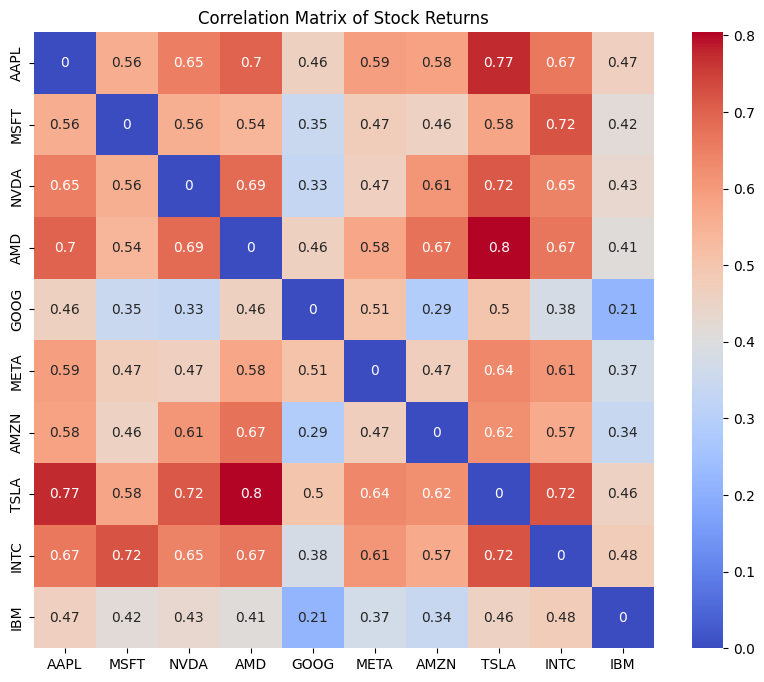

In [6]:
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(stock_graph(y_train), annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of Stock Returns')
plt.show()

/var/folders/d0/1nn98jmj4gn_7vzw374_ds4c0000gn/T/ipykernel_26674/281005117.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.graph = torch.tensor(corr)


Epoch 10, Loss: 0.000735
Epoch 20, Loss: 0.000736
Epoch 30, Loss: 0.000732
Epoch 40, Loss: 0.000732
Epoch 50, Loss: 0.000732
Epoch 60, Loss: 0.000732
Epoch 70, Loss: 0.000732
Epoch 80, Loss: 0.000732
Epoch 90, Loss: 0.000732
Epoch 100, Loss: 0.000732


ValueError: x and y must have same first dimension, but have shapes (807,) and (806,)

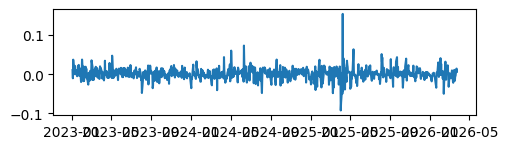

In [8]:
# Plot test error
corr = stock_graph(y_train)       # correlation matrix
corr = normalize_graph(corr)      # optional normalization
corr = torch.tensor(corr, dtype=torch.float32)

k = 3  # number of filter taps
model = graph_filter(corr, k)

x_train_tensor = torch.tensor(y_train.values[:-1], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values[1:], dtype=torch.float32)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 100

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Forward pass
    y_pred = model(x_train_tensor)
    
    # Compute loss
    loss = criterion(y_pred, y_train_tensor)
    
    # Backprop
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

x_test_tensor = torch.tensor(ytest.values[:-1], dtype=torch.float32)
y_test_tensor = torch.tensor(ytest.values[1:], dtype=torch.float32)

# Plot predicted vs actual returns per stock
plt.figure(figsize=(12, 8))
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(ytest.index, ytest[ticker], label='Actual Returns')
    plt.plot(ytest.index, y_test_tensor[:, i].detach().numpy(), label='Predicted Returns')
    plt.title(f'{ticker} Returns')
    plt.xlabel('Date')
    plt.ylabel('Returns')
    plt.legend()
plt.tight_layout()
plt.show()

# Validation Loss
criterion = nn.MSELoss()
with torch.no_grad():
    val_loss = criterion(y_pred_test, x_test_tensor)
print(f"Validation Loss: {val_loss.item():.6f}")  



In [ ]:
class graph_perceptron(nn.Module):
    def __init__(self, gso, k, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.sigma = sigma
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        y = filter_function(self.weight, self.gso, x)
        y = self.sigma(y)
        return y    

In [ ]:
# for multi features add: past 5 days data, moving average, volatility, etc.